# 8. Hyperparameter Tuning

1. Import Libraries

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

2. Load Dataset

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

3. Remove Unnecessary Columns

In [3]:
df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace =True
)

4. Encode Target

In [4]:
le = LabelEncoder()

df["Attrition"] = le.fit_transform(df["Attrition"])

5. Split Features and Target

In [5]:
x = df.drop("Attrition", axis = 1)
y = df["Attrition"]

6. Identify Numerical and Categorical Columns

In [6]:
numerical_columns = x.select_dtypes(include=["int64"]).columns
categorical_columns = x.select_dtypes(include=["object"]).columns

/var/folders/83/lyk88fr96bq5vfw5v_m3j0n40000gn/T/ipykernel_62061/2031502495.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x.select_dtypes(include=["object"]).columns


7. Create Preprocessor

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical_columns
        )
    ]
)

8. Train-Test Split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

9. Build Pipeline

In [10]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state = 42))
])

10. Hyperparameter Grid

In [35]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],

    "classifier__solver": [
        "liblinear",
        "lbfgs"
    ],

    "classifier__penalty": [
        "l2"
    ]
}

## Key Points

### What is `param_grid`?
A list of hyperparameter values that **GridSearchCV** will try to find the best model.

### Hyperparameters

#### `C`
- Controls how strictly the model fits the training data.
- Small `C` → Simpler model (less overfitting).
- Large `C` → Fits training data more closely (may overfit).

#### `solver`
The algorithm used to train Logistic Regression.

- `liblinear`
- `lbfgs`

#### `penalty`
Method used to reduce overfitting.

- `l2` → Keeps model coefficients from becoming too large.

#### Why only `l2`?

- `lbfgs` supports only **l2**.
- `liblinear` supports **l1** and **l2**.

Using only **l2** avoids invalid combinations and keeps GridSearch simple.

#### Total Models Tested

```
C values      = 5
Solver values = 2
Penalty values= 1

Total = 5 × 2 × 1 = 10 models
```

11. Grid Search

In [36]:
grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    cv = 5,
    scoring = "f1",
    n_jobs = -1
)

## Key Points

1. **estimator** → Model/Pipeline to optimize.
2. **param_grid** → Hyperparameters to test.
3. **cv=5** → 5-Fold Cross Validation.
4. **scoring="f1"** → Choose the model with the highest F1 Score.
5. **n_jobs=-1** → Use all CPU cores for faster execution.

### Why `scoring="f1"`?

- Best for **imbalanced datasets**.
- Balances **Precision** and **Recall**.

12. Train

In [37]:
grid_search.fit(
    x_train,
    y_train
)

/Users/vivekkumar/Desktop/project/Employee-Attrition-Prediction/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/vivekkumar/Desktop/project/Employee-Attrition-Prediction/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l2'], 'classifier__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: 

13. Best Parameters

In [38]:
grid_search.best_params_

{'classifier__C': 100,
 'classifier__penalty': 'l2',
 'classifier__solver': 'liblinear'}

14. Best Model

In [39]:
best_model = grid_search.best_estimator_

15. Predictions

In [40]:
y_pred = best_model.predict(x_test)

16. Evaluate Again

In [41]:
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 :", f1_score(y_test, y_pred))
print("ROC-AUC :",roc_auc_score(y_test,y_pred))

Accuracy : 0.8571428571428571
Precision:  0.5925925925925926
Recall : 0.3404255319148936
F1 : 0.43243243243243246
ROC-AUC : 0.6479455594797141


17. Confusion Matrix

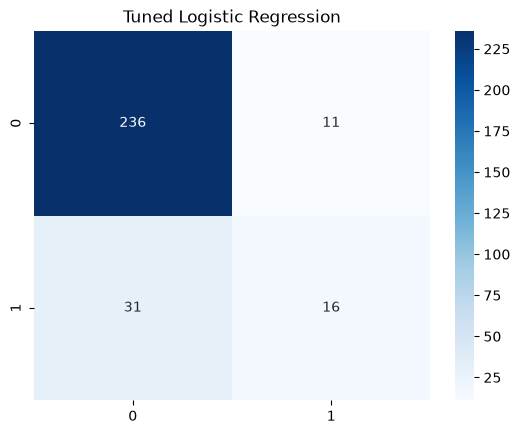

In [46]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot = True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Logistic Regression")
plt.show()

## Observation

### Objective
Optimize the best-performing baseline model (Logistic Regression) using GridSearchCV and evaluate whether hyperparameter tuning improves the model's performance.

### Tasks Performed
- Selected Logistic Regression as the baseline model based on Phase 7 evaluation.
- Created a preprocessing and modeling pipeline using Scikit-Learn Pipeline.
- Defined a hyperparameter search space (`C`, `solver`, and `penalty`).
- Applied `GridSearchCV` with 5-fold cross-validation.
- Optimized the model using **F1 Score** as the scoring metric.
- Retrieved the best hyperparameter combination.
- Evaluated the tuned model on the test dataset.
- Compared the tuned model with the baseline model.

### Baseline Model Performance

| Metric | Score |
|---------|------:|
| Accuracy | **0.8639** |
| Precision | **0.6400** |
| Recall | **0.3404** |
| F1 Score | **0.4444** |
| ROC-AUC | **0.6520** |

### Tuned Model Performance

| Metric | Score |
|---------|------:|
| Accuracy | **0.8571** |
| Precision | **0.5926** |
| Recall | **0.3404** |
| F1 Score | **0.4324** |
| ROC-AUC | **0.6479** |

### Observations
- Hyperparameter tuning was performed using `GridSearchCV` with 5-fold cross-validation.
- The tuned model did **not** outperform the baseline Logistic Regression model on the test dataset.
- The baseline model achieved higher Accuracy, Precision, F1 Score, and ROC-AUC, while Recall remained unchanged.
- This demonstrates that hyperparameter tuning does not always improve model performance and highlights the importance of validating improvements on unseen test data.

### Final Model Selection
Based on the evaluation metrics, the **baseline Logistic Regression model** was selected as the final model because it achieved the highest overall F1 Score and ROC-AUC while maintaining the best balance between Precision, Recall, and Accuracy.

### Key Learnings
- Hyperparameter tuning is an optimization technique, not a guarantee of better performance.
- Model selection should always be based on evaluation results rather than assuming a tuned model is superior.
- F1 Score was chosen as the primary evaluation metric due to the class imbalance in the dataset.
- Comparing baseline and tuned models is an essential step in building reliable machine learning solutions.

### Outcome
The baseline Logistic Regression model was selected as the final production model and will be used for model serialization, deployment, and application development in the upcoming phases.